# Task 1: Importing Libraries

In [1]:
import os
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.preprocessing.image import ImageDataGenerator

# Task 2: Load the Dataset

In [2]:
# Define a common image size so all inputs are uniform for the model
img_dims = 64

def load_data(directory, _shear_range=0, _zoom_range=0, _horizontal_flip=False):
    # ImageDataGenerator handles on-the-fly preprocessing and augmentation
    # This keeps memory usage low and avoids storing transformed images on disk
    train_datagen = ImageDataGenerator(
        rescale=1.0/255,             # Normalize pixel values for stable training
        shear_range=_shear_range,    # Apply geometric distortion if enabled
        zoom_range=_zoom_range,      # Simulate different camera distances
        horizontal_flip=_horizontal_flip  # Improve generalization for symmetric objects
    )
    
    # flow_from_directory automatically infers class labels from folder names
    # and yields batches of preprocessed images during training
    data = train_datagen.flow_from_directory(
        directory,
        target_size=(img_dims, img_dims),  # Resize all images to a fixed shape
        batch_size=8,                      # Small batch size suitable for limited resources
        class_mode='binary',               # Binary labels for two-class classification
        color_mode="grayscale"             # Reduce input complexity and computation
    )
    
    return data

# Load training data with augmentation enabled to improve robustness
training_set = load_data("/usercode/dataset/training_set", 0.2, 0.2, True)

# Load validation data without augmentation to evaluate real-world performance
validate_set = load_data("/usercode/dataset/validation_set")

Found 1000 images belonging to 2 classes.
Found 250 images belonging to 2 classes.


# Task 3: Visualize the Dataset

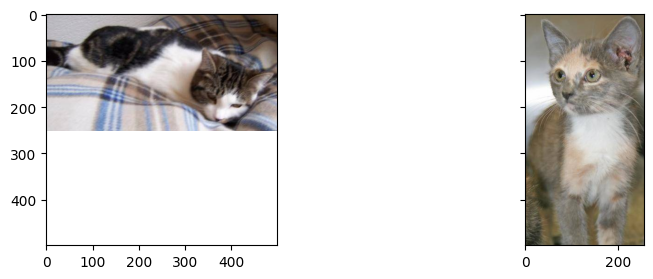

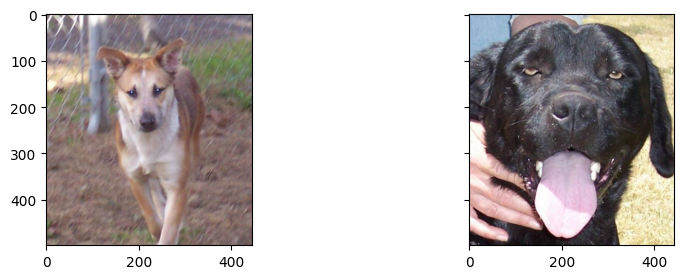

In [3]:
def display_images(path,directory_list):
   # Create a small horizontal grid to compare multiple images side by side
   fig,ax=plt.subplots(1,2,figsize=(10,3),sharex='col',sharey='row')

   indx=0
   for image_name in directory_list:
      # Build the full file path in a platform-independent way
      input_path = os.path.join(path, image_name)
      
      # Read the image file into an array that matplotlib can render
      img=plt.imread(input_path)
      
      # Display the image in the corresponding subplot
      ax[indx].imshow(img)
      
      # Move to the next subplot
      indx+=1

# Point to individual class folders so images are easy to sample
cat_directory = "/usercode/dataset/training_set/cat"
dog_directory = "/usercode/dataset/training_set/dog"

# Display a small sample from each class to visually inspect the dataset
display_images(cat_directory,os.listdir(cat_directory)[0:2])
display_images(dog_directory,os.listdir(dog_directory)[0:2])

# Task 4: Create an Instance of the Neural Network

In [4]:
# Initialize a sequential model which allows stacking layers linearly
# Suitable for a simple CNN with one input and one output
model=tf.keras.models.Sequential()

# Task 5: Adding the Layers to the CNN

In [5]:
# Add a convolutional layer to extract feature maps from the input images
# 16 filters, 3x3 kernel, ReLU activation, input shape matches the preprocessed images
model.add(tf.keras.layers.Conv2D(filters=16,kernel_size=3,activation='relu',input_shape=(img_dims,img_dims,1)))

# Apply max pooling to reduce spatial dimensions and computation
# Pool size of 2x2 with stride 2 downsamples feature maps by half
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

# Flatten the pooled feature maps into a 1D vector for the dense layers
model.add(tf.keras.layers.Flatten())

# Add a dense layer to learn high-level representations
# 128 neurons with ReLU activation for non-linear feature learning
model.add(tf.keras.layers.Dense(units=128,activation='relu'))

# Output layer with a single neuron and sigmoid activation for binary classification
model.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))

# Print a summary of the model architecture for verification
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 16)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 15376)             0         
                                                                 
 dense (Dense)               (None, 128)               1968256   
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1,968,545
Trainable params: 1,968,545
Non-trainable params: 0
______________________________________________

# Task 6: Compile the Model


In [6]:
# Initialize the Adam optimizer with a small learning rate for stable convergence
optmz = Adam(learning_rate=0.0001)

# Compile the model with the optimizer, binary cross-entropy loss for two-class classification,
# and accuracy as the evaluation metric during training
model.compile(optimizer=optmz,loss='binary_crossentropy',metrics=['accuracy'])

# Task 7: Train the CNN

In [7]:
# Train the CNN on the training set while evaluating performance on the validation set
# 30 epochs define the number of full passes over the training data
history=model.fit(x=training_set,validation_data=validate_set,epochs=30)

Epoch 1/30
125/125 [==============================] - 11s 81ms/step - loss: 0.7283 - accuracy: 0.5190 - val_loss: 0.7046 - val_accuracy: 0.5000
Epoch 2/30
125/125 [==============================] - 8s 64ms/step - loss: 0.7098 - accuracy: 0.5150 - val_loss: 0.6990 - val_accuracy: 0.4880
Epoch 3/30
125/125 [==============================] - 8s 64ms/step - loss: 0.6921 - accuracy: 0.5500 - val_loss: 0.6886 - val_accuracy: 0.5440
Epoch 4/30
125/125 [==============================] - 10s 77ms/step - loss: 0.6832 - accuracy: 0.5560 - val_loss: 0.6909 - val_accuracy: 0.5080
Epoch 5/30
125/125 [==============================] - 8s 64ms/step - loss: 0.6850 - accuracy: 0.5530 - val_loss: 0.6860 - val_accuracy: 0.5200
Epoch 6/30
125/125 [==============================] - 8s 67ms/step - loss: 0.6789 - accuracy: 0.5710 - val_loss: 0.6916 - val_accuracy: 0.5160
Epoch 7/30
125/125 [==============================] - 10s 79ms/step - loss: 0.6797 - accuracy: 0.5770 - val_loss: 0.7053 - val_accuracy: 0.5

# Task 8: Test the CNN

In [8]:
# Create an ImageDataGenerator for the test set; only rescaling is needed, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load the test images from the directory in a format compatible with the model
# batch_size=1 allows evaluation image by image
# shuffle=False preserves the original order for consistent evaluation
test_itr = test_datagen.flow_from_directory(
   "/usercode/dataset/test_set",
   target_size=(img_dims, img_dims),   # Resize images to match training dimensions
   batch_size=1,
   color_mode='grayscale',             # Match the input color mode used in training
   class_mode='binary',                # Binary classification labels
   shuffle=False
)

# Evaluate the model on the test data to get loss and accuracy
loss, accuracy = model.evaluate(test_itr)

# Display the test performance
print("Accuracy: ", accuracy, ", Loss: ", loss)

Found 100 images belonging to 2 classes.
100/100 [==============================] - 1s 5ms/step - loss: 0.7644 - accuracy: 0.5500
Accuracy:  0.550000011920929 , Loss:  0.7643696069717407


# Task 9: Visualize the Metrics

In [ ]:
# Extract the training metrics from the History object returned by model.fit
history=history.history

In [ ]:
# Plot training and validation loss over epochs to monitor convergence
plt.plot(history['loss'], label='Training loss',color='r')
plt.plot(history['val_loss'], label='Validation loss',color='b')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Plot training and validation accuracy over epochs to monitor performance
plt.plot(history['accuracy'], label='Training accuracy',color='r')
plt.plot(history['val_accuracy'], label='Validation accuracy',color='b')
plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Load previously saved training metrics for visualization
import pickle
with open("/usercode/trained-model-history.pickle",'rb') as file: 
    history = pickle.load(file)         # Restores metrics for plotting or analysis

# Task 10: Plot the Confusion Matrix


In [ ]:
# Make predictions on the test set; suppress batch output for clarity
results = model.predict(test_itr, verbose=0)

# Round the predicted probabilities to 0 or 1 for binary classification
results = np.round(results)

# Get the true class labels from the test iterator
true_vals = test_itr.classes

# Generate the confusion matrix using TensorFlow
confusion_mtx = tf.math.confusion_matrix(true_vals, results)

# Plot the confusion matrix as a heatmap using seaborn
# Annotate=True shows the count values inside the squares
# fmt='g' ensures numbers are shown as integers
sns.heatmap(confusion_mtx, cmap=plt.cm.Blues, annot=True, fmt='g')

# Label the axes for clarity: predicted vs true classes
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()